## Project Overview

Sweet Lift Taxi company has collected historical data on taxi orders at airports. To attract more drivers during peak hours, we need to predict the amount of taxi orders for the next hour.

* The data is stored in /datasets/taxi.csv
* The number of orders is in the num_orders column.



# Initaliztion

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor

In [2]:
data = pd.read_csv('/datasets/taxi.csv')

In [3]:
data['datetime'] = pd.to_datetime(data['datetime'])

In [4]:
data = data.set_index('datetime').resample('H').sum()

# Exploratory Data Analysis

In [5]:
data.duplicated().sum()

4165

No true duplicates.

In [6]:
data.isna().sum()

num_orders    0
dtype: int64

In [7]:
data.describe()

,num_orders
count,4416.000000
mean,84.422781
std,45.023853
min,0.000000
25%,54.000000
50%,78.000000
75%,107.000000
max,462.000000


There are 4416 hours recorded, with the number of rides  ranging from 0 and to a max of 462. The average number of rides per hour is 84.422781.

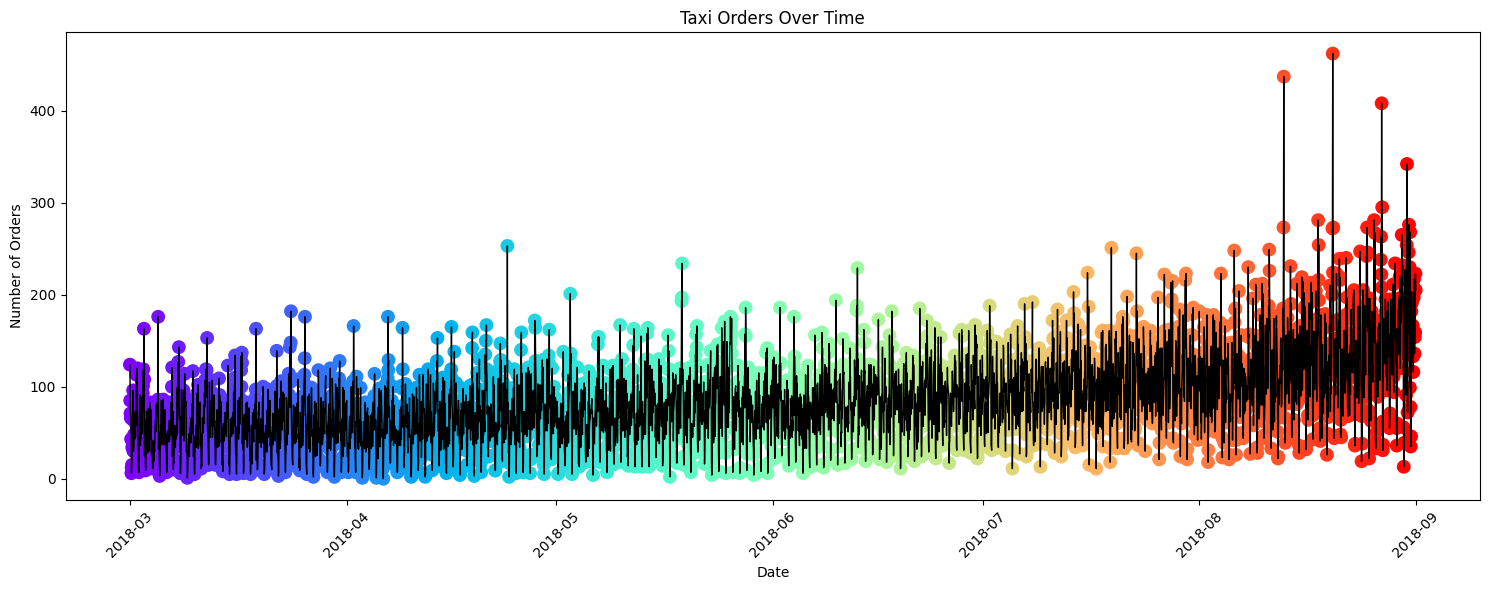

In [8]:
plt.figure(figsize=(15, 6))
plt.plot(data.index, data['num_orders'], color = 'black', linewidth = 1)
colors = plt.cm.rainbow(np.linspace(0, 1, len(data)))
plt.scatter(data.index, data['num_orders'], c = colors, s = 80)
plt.title('Taxi Orders Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

It looks like taxi activity increases during the summer months. 

In [9]:
data['day_of_week'] = data.index.dayofweek

In [10]:
weekly_pattern = data.groupby('day_of_week')['num_orders'].mean()

In [11]:
day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekly_pattern.index = day_names

In [12]:
weekly_pattern

Monday       90.246795
Tuesday      77.011218
Wednesday    83.754808
Thursday     85.660494
Friday       91.140432
Saturday     83.847756
Sunday       78.991987
Name: num_orders, dtype: float64

Day of the week that are the busiest: Friday, Monday, Thursday.

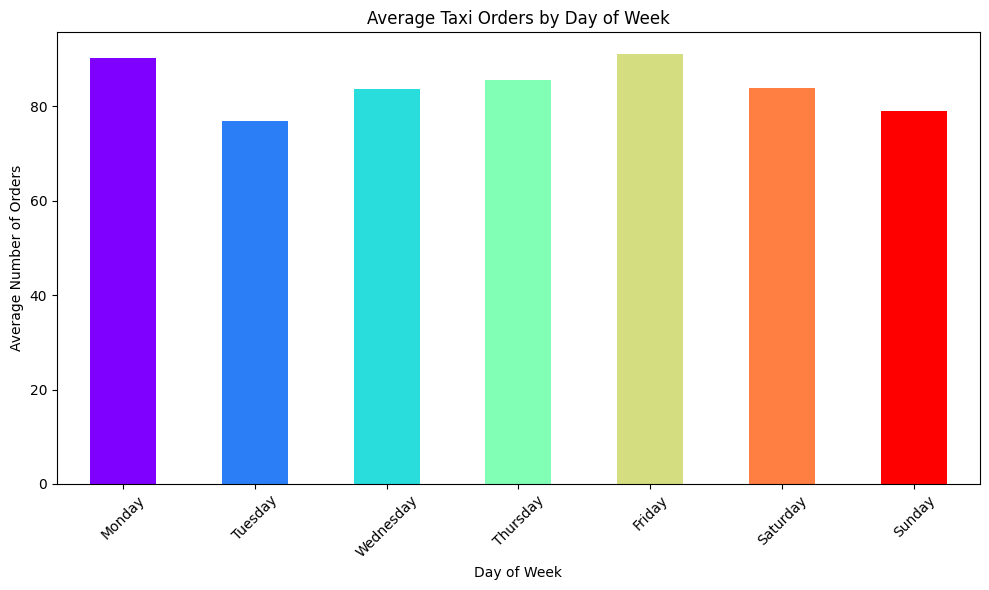

In [13]:
colors = plt.cm.rainbow(np.linspace(0,1, len(weekly_pattern)))
plt.figure(figsize=(10, 6))
weekly_pattern.plot(kind='bar', color = colors)
plt.title('Average Taxi Orders by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Number of Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [14]:
data['hour'] = data.index.hour

In [15]:
hourly_pattern = data.groupby('hour')['num_orders'].mean()

In [16]:
hourly_pattern

hour
0     144.402174
1     104.364130
2     113.070652
3     102.021739
4      86.907609
5      42.630435
6      25.173913
7      29.271739
8      73.048913
9      88.831522
10     93.119565
11     82.489130
12     67.630435
13     71.173913
14     75.163043
15     87.945652
16    114.146739
17     92.722826
18     69.358696
19     77.336957
20     81.858696
21     95.211957
22     98.500000
23    109.766304
Name: num_orders, dtype: float64

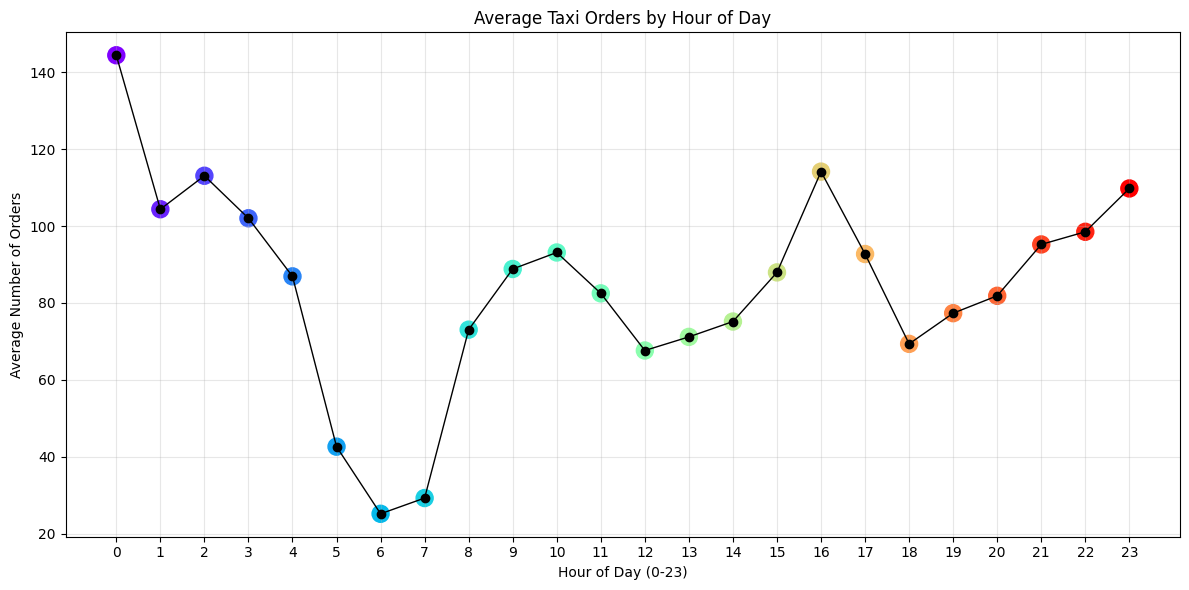

In [17]:
plt.figure(figsize=(12, 6))
colors = plt.cm.rainbow(np.linspace(0, 1, len(hourly_pattern)))
plt.plot(hourly_pattern.index, hourly_pattern.values, marker = 'o', color = 'black', linewidth = 1)
plt.scatter(hourly_pattern.index, hourly_pattern.values, c = colors, s = 150)
plt.title('Average Taxi Orders by Hour of Day')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Average Number of Orders')
plt.grid(True, alpha=0.3)
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

12am is the busiest time by far, with 6am being the slowest. 

# Training

In [18]:
df = data.copy()

In [19]:
df['lag_1'] = df['num_orders'].shift(1)

In [20]:
df['lag_24'] = df['num_orders'].shift(24)

In [21]:
df['lag_168'] = df['num_orders'].shift(168)

In [22]:
df['rolling_mean_24'] = df['num_orders'].rolling(window=24).mean().shift(1)

In [23]:
df['rolling_mean_168'] = df['num_orders'].rolling(window=168).mean().shift(1)

In [24]:
df = df.dropna()

In [25]:
f"Dataset shape after feature engineering: {df.shape}"

'Dataset shape after feature engineering: (4248, 8)'

In [26]:
f"Features created: {df.columns.tolist()}"

"Features created: ['num_orders', 'day_of_week', 'hour', 'lag_1', 'lag_24', 'lag_168', 'rolling_mean_24', 'rolling_mean_168']"

In [27]:
df.head(20)

,num_orders,day_of_week,hour,lag_1,lag_24,lag_168,rolling_mean_24,rolling_mean_168
datetime,,,,,,,,
2018-03-08 00:00:00,143,3,0,94.0,100.0,124.0,60.041667,54.226190
2018-03-08 01:00:00,78,3,1,143.0,121.0,85.0,61.833333,54.339286
2018-03-08 02:00:00,65,3,2,78.0,24.0,71.0,60.041667,54.297619
2018-03-08 03:00:00,68,3,3,65.0,66.0,66.0,61.750000,54.261905
2018-03-08 04:00:00,60,3,4,68.0,73.0,43.0,61.833333,54.273810
2018-03-08 05:00:00,6,3,5,60.0,10.0,6.0,61.291667,54.375000
2018-03-08 06:00:00,6,3,6,6.0,19.0,12.0,61.125000,54.375000
2018-03-08 07:00:00,19,3,7,6.0,17.0,15.0,60.583333,54.339286
2018-03-08 08:00:00,77,3,8,19.0,38.0,34.0,60.666667,54.363095


In [28]:
feature = df[['hour', 'day_of_week', 'lag_1', 'lag_24', 'lag_168', 
                   'rolling_mean_24', 'rolling_mean_168']]

In [29]:
target = df['num_orders']

In [30]:
feature_train, feature_test, target_train, target_test = train_test_split(
    feature, target, test_size=0.1, random_state=42, shuffle=False
)

## RandomForestRegressor

In [31]:
results = []

for depth in [10, 12, 15]:
    for n_estimators in [100, 200, 300]:
        model = RandomForestRegressor(
            n_estimators=n_estimators,
            max_depth=depth,
            random_state=42,
            n_jobs=-1
        )
        model.fit(feature_train, target_train)
        preds = model.predict(feature_test)
        rmse = np.sqrt(mean_squared_error(target_test, preds))
        results.append((depth, n_estimators, rmse))

rf_results_df = pd.DataFrame(results, columns=['depth', 'n_estimators', 'rmse'])
print("Best Combination:")
print(rf_results_df.nsmallest(1, 'rmse'))

Best Combination:
   depth  n_estimators       rmse
8     15           300  42.888519


In [32]:
model = RandomForestRegressor(random_state=42, n_estimators=300, max_depth=15)
model.fit(feature_train, target_train)
pred_test = model.predict(feature_test)
rmse = np.sqrt(mean_squared_error(target_test, pred_test))
f"Test RMSE: {rmse:.2f}"

'Test RMSE: 42.89'

## XGBoost

In [33]:
results = []
for learning_rate in [.005, .01, .02]:
    for max_depth in [3, 4, 5, 6]:
        for n_estimators in [50, 100, 300, 500]:
            
            model = XGBRegressor(
                learning_rate=learning_rate,
                n_estimators=n_estimators,
                max_depth=max_depth,
                random_state=42,
                n_jobs=-1
            )
            
            model.fit(feature_train, target_train)
            preds = model.predict(feature_test)
            rmse = np.sqrt(mean_squared_error(target_test, preds))
            results.append((learning_rate, max_depth, n_estimators, rmse))


xgb_results_df = pd.DataFrame(results, columns=['learning_rate', 'max_depth', 'n_estimators', 'rmse'])
print("Best Combination:")
print(xgb_results_df.nsmallest(1, 'rmse'))

Best Combination:
    learning_rate  max_depth  n_estimators       rmse
38           0.02          4           300  41.448614


In [34]:
model = XGBRegressor(
    learning_rate=.02,
    max_depth=4,
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

model.fit(feature_train, target_train)
pred_test = model.predict(feature_test)
rmse = np.sqrt(mean_squared_error(target_test, pred_test))
f"Test RMSE: {rmse:.2f}"

'Test RMSE: 41.45'

## Final Conclusion

Sweet Lift Taxi Company requested historical airport taxi order data to build a model capable of predicting future peak demand hours.

After analyzing the dataset, the following insights were identified:

- The average number of rides per hour is **84.42**.
- Taxi demand increases during the summer months, with the highest activity occurring between **August and September**.
- The busiest days of the week are **Friday, Monday, and Thursday**.
- The highest hourly demand occurs during **00:00–03:00** and **15:30–17:30**.
- The lowest demand period is **04:30–07:30**.

Two machine learning models were trained and evaluated:

- **RandomForestRegressor** provided strong performance with faster training time and achieved a minimum RMSE of **42.89**.
- **XGBoostRegressor** required longer training time but achieved the best predictive performance with a minimum RMSE of **41.45**.

Since the project requirement specifies an RMSE not exceeding 48, both models satisfy the acceptance criteria.

If maximum accuracy is the priority, **XGBoost is the recommended model**.  
If faster training and simpler deployment are preferred while maintaining high accuracy, **Random Forest is an excellent alternative**.